### Data Ingestion

In [9]:
### Document Structure

from langchain_core.documents import Document



In [10]:
doc=Document(page_content="This is the main text content I am using to create RAG",
metadata={
    "source": "example.txt", 
    "author": "Sivani",
    "pages":1,
    "date_created":"2025-11-25"}
)   # Why we are using this because we can filter our data based on metadata while retrieving

In [11]:
doc

Document(metadata={'source': 'example.txt', 'author': 'Sivani', 'pages': 1, 'date_created': '2025-11-25'}, page_content='This is the main text content I am using to create RAG')

In [12]:
### Create a simple txt file
import os
os.makedirs("../data/text_files", exist_ok=True)


In [13]:
sample_texts={
    "../data/text_files/python_intro.txt":"""Python Programming Introduction

Python is a high-level, interpreted programming language known for its simplicity and readability.
Created by Guido van Rossum and first released in 1991, Python has become one of the most popular
programming languages in the world.

Key Features:
- Easy to learn and use
- Extensive standard library
- Cross-platform compatibility
- Strong community support

Python is widely used in web development, data science, artificial intelligence, and automation.""",
    
    "../data/text_files/machine_learning.txt": """Machine Learning Basics

Machine learning is a subset of artificial intelligence that enables systems to learn and improve
from experience without being explicitly programmed. It focuses on developing computer programs
that can access data and use it to learn for themselves.

Types of Machine Learning:
1. Supervised Learning: Learning with labeled data
2. Unsupervised Learning: Finding patterns in unlabeled data
3. Reinforcement Learning: Learning through rewards and penalties

Applications include image recognition, speech processing, and recommendation systems
    
    
    """

}
for filepath,content in sample_texts.items():
    with open(filepath,"w",encoding="utf-8") as f:
        f.write(content)
print("✅Sample text files created.")


✅Sample text files created.


In [20]:
### TextLoader
from langchain_community.document_loaders import TextLoader

loader=TextLoader("../data/text_files/python_intro.txt", encoding="utf-8")
document=loader.load()  # returns list of Document objects
print(document)

[Document(metadata={'source': '../data/text_files/python_intro.txt'}, page_content='Python Programming Introduction\n\nPython is a high-level, interpreted programming language known for its simplicity and readability.\nCreated by Guido van Rossum and first released in 1991, Python has become one of the most popular\nprogramming languages in the world.\n\nKey Features:\n- Easy to learn and use\n- Extensive standard library\n- Cross-platform compatibility\n- Strong community support\n\nPython is widely used in web development, data science, artificial intelligence, and automation.')]


In [28]:
### Directory Loader
from langchain_community.document_loaders import DirectoryLoader

###load all the text files from the directory
dir_loader=DirectoryLoader("../data/text_files",
                    glob="**/*.txt",
                    loader_cls=TextLoader,                               #pattern to match files
                    loader_kwargs={"encoding":"utf-8"},
                    )
documents=dir_loader.load()
documents

[Document(metadata={'source': '..\\data\\text_files\\machine_learning.txt'}, page_content='Machine Learning Basics\n\nMachine learning is a subset of artificial intelligence that enables systems to learn and improve\nfrom experience without being explicitly programmed. It focuses on developing computer programs\nthat can access data and use it to learn for themselves.\n\nTypes of Machine Learning:\n1. Supervised Learning: Learning with labeled data\n2. Unsupervised Learning: Finding patterns in unlabeled data\n3. Reinforcement Learning: Learning through rewards and penalties\n\nApplications include image recognition, speech processing, and recommendation systems\n\n\n    '),
 Document(metadata={'source': '..\\data\\text_files\\python_intro.txt'}, page_content='Python Programming Introduction\n\nPython is a high-level, interpreted programming language known for its simplicity and readability.\nCreated by Guido van Rossum and first released in 1991, Python has become one of the most popu

In [35]:
###pdf loader
from langchain_community.document_loaders import PyPDFLoader,PyMuPDFLoader


###load all the text files from the directory
dir_loader=DirectoryLoader("../data/pdf/",
                    glob="**/*.pdf",
                    loader_cls=PyMuPDFLoader,                               #pattern to match files,
                    show_progress=True
                    )
pdf_documents=dir_loader.load()
pdf_documents

100%|██████████| 2/2 [00:02<00:00,  1.21s/it]


[Document(metadata={'producer': '3-Heights™ PDF Merge Split Shell 6.12.1.11 (http://www.pdf-tools.com)', 'creator': '', 'creationdate': '', 'source': '..\\data\\pdf\\Harsha Verse Webdev Sheet.pdf', 'file_path': '..\\data\\pdf\\Harsha Verse Webdev Sheet.pdf', 'total_pages': 8, 'format': 'PDF 1.6', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'moddate': '2024-12-23T07:28:15+00:00', 'trapped': '', 'modDate': 'D:20241223072815Z', 'creationDate': '', 'page': 0}, page_content="Harsha Verse\nHARSHA VERSE WEB DEV SHEET\nOVERVIEW:\nWeb Development is the process of building and maintaining websites and web applications. It\nincludes creating everything from simple landing pages to complex, interactive websites,\ninvolving both front-end (user-facing) and back-end (server-side) development.\nWhy it's still relevant and highly paid in 2025:\n1.\nUniversal Need for Online Presence: In today’s digital-first world, nearly every\nbusiness, from small startups to large enterprises, needs 

In [38]:
type(pdf_documents[0])

langchain_core.documents.base.Document

In [ ]:
### For EXcel, DB --> refer to the langchain documentation

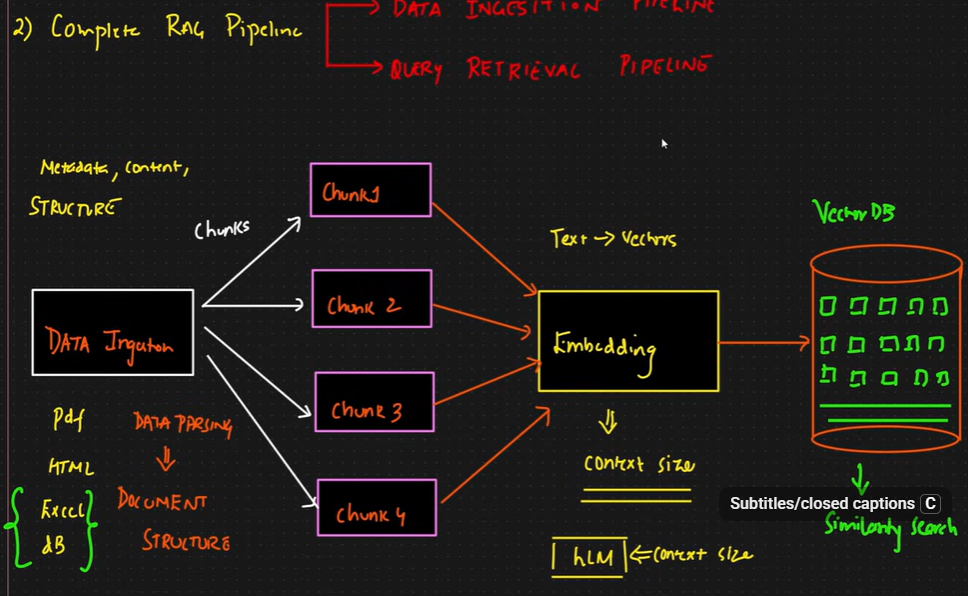

### Chunking